In [1]:
import panda_control
import panda_control.robot
import numpy as np
from copy import deepcopy
import time
import matplotlib.pyplot as plt
import torch
from robot_grasping_sim.env.states import State, InternalState
import pick_env
import pick_env.env

def show_image(image,ref_image=None, show_tactile:bool=False):
    def convert(img, normalized:bool=False):
        if isinstance(img, torch.Tensor):
            img = img.detach().cpu().numpy()
        
        if img.shape[0] == 3:
            img = img.transpose(1,2,0)

        if img.max()>1.0 and normalized:
            img = img / 255.0
        return img

    if show_tactile:
        image = convert(image)
        image = np.linalg.norm(image,axis=-1)
    else:
        image = convert(image,True)
    if ref_image is not None:
        if show_tactile:
            ref_image = convert(ref_image)
            ref_image = np.linalg.norm(ref_image,axis=-1)
        else:
            ref_image = convert(ref_image,True)
        fig, axes = plt.subplots(1, 2, figsize=(10, 5))
        axes[0].imshow(image)
        axes[1].imshow(ref_image)
        axes[0].set_title('image')
        axes[1].set_title('ref_image')
    else:
        plt.imshow(image)

    plt.show()

def init_robot(controller_cfg_dir:str= "../config", interface_cfg:str = "../config/charmander.yml"):
    home_joint_positions = np.array([0.180677,-0.11398,-0.13509,-2.03183,0.0351661,1.89308,0.811476, 0.08])
    robot = panda_control.robot.Robot(controller_cfg_dir = controller_cfg_dir, interface_cfg = interface_cfg, home_joint_positions=home_joint_positions)
    return robot

def init_env():
    config_file_path = "rl_methods/config/mpo_batch.yaml"
    device = f'cuda:0'
    dtype=torch.float64

    #* Init ENV
    from robot_grasping_sim.utils.io import load_config
    actor_config = load_config(path=config_file_path)
    env = pick_env.env.Env(actor_config=actor_config, dtype=dtype, device=device)
    return env


pybullet build time: Nov 28 2023 23:51:11


In [2]:
import torchvision.transforms.functional as F
def to_tensor(img):
    def rgb2gray(rgb):
        gray = np.dot(rgb[...,:3], [0.2989, 0.5870, 0.1140])
        return  np.tile(gray[...,np.newaxis],(1,1,3))
    gray = rgb2gray(img)
    return torch.from_numpy(gray).to(dtype=torch.float64, device="cuda").permute(2,0,1)[None,...]/255.0

from typing import List
def show_images_from_states(states:List[State],show_tactile=False,save_path:str=None):
    def convert(img, normalized:bool=False):
        if isinstance(img, torch.Tensor):
            img = img.detach().cpu().numpy()
        
        if img.shape[0] == 3:
            img = img.transpose(1,2,0)

        if img.max()>1.0 and normalized:
            img = img / 255.0
        return img
    
    fig, axes = plt.subplots(10, 10, figsize=(30, 30))
    for i,state in enumerate(states):
        if show_tactile:
            image = convert(state.tactile_force_image[1][0],False)
            image = np.linalg.norm(image,axis=-1)
        else:
            image = convert(state.wrist_camera_rgb_image[0],True)
        axes.flatten()[i].imshow(image)
        axes.flatten()[i].set_title(f'{i}')
    fig.tight_layout()
    if save_path is not None:
        plt.savefig(f'{save_path}.png')
    plt.show()

In [3]:
env = init_env()
time.sleep(1.0)

Load handeye transformation:
[[ 0.01428488 -0.99867627  0.04941305  0.05922682]
 [ 0.99956338  0.01298432 -0.02654165 -0.03407072]
 [ 0.02586492  0.04977062  0.99842571 -0.08292535]
 [ 0.          0.          0.          1.        ]]


Corrupt JPEG data: 32 extraneous bytes before marker 0xdb


use_gpu:True
Doing force map estimation
Loading checkpoint
Wandb ID: u3l2s99i: 
Testing fully trained model


Corrupt JPEG data: 32 extraneous bytes before marker 0xdb


Init Foundation Pose


num original candidates = 252
num of pose after clustering: 252


[Pose Perceptor] Pre estimating...


Module Utils load on device 'cuda:0' took 5.51 ms
[Pose Perceptor] Ready


[predict()] forward done
[predict()] making cropped data
[make_crop_data_batch()] Welcome make_crop_data_batch
[make_crop_data_batch()] make tf_to_crops done
[make_crop_data_batch()] render done
[make_crop_data_batch()] warp done
[make_crop_data_batch()] pose batch data done
[predict()] forward start
[predict()] forward done
[predict()] making cropped data
[make_crop_data_batch()] Welcome make_crop_data_batch
[make_crop_data_batch()] make tf_to_crops done
[make_crop_data_batch()] render done
[make_crop_data_batch()] warp done
[make_crop_data_batch()] pose batch data done
[predict()] forward start
[predict()] forward done
[predict()] making cropped data
[make_crop_data_batch()] Welcome make_crop_data_batch
[make_crop_data_batch()] make tf_to_crops done
[make_crop_data_batch()] render done
[make_crop_data_batch()] warp done
[make_crop_data_batch()] pose batch data done
[predict()] forward start


In [4]:
import rl_methods.encoder.ae_image_encoder as ae_image_encoder
encoder_config_file = "rl_methods/config/encoders/image_ae/pretrain_encoder.yaml"
image_encoder = ae_image_encoder.create_encoder(encoder_config_file)

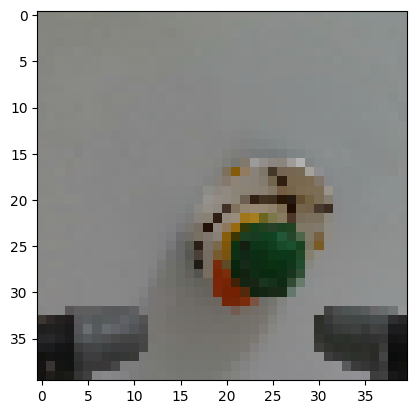

In [5]:
rgb_img = env.vision_perceptor.last_state[0].rgb
# rgb_img = env.tactile_perceptor.last_state.force_map_right
show_image(rgb_img, show_tactile=False)

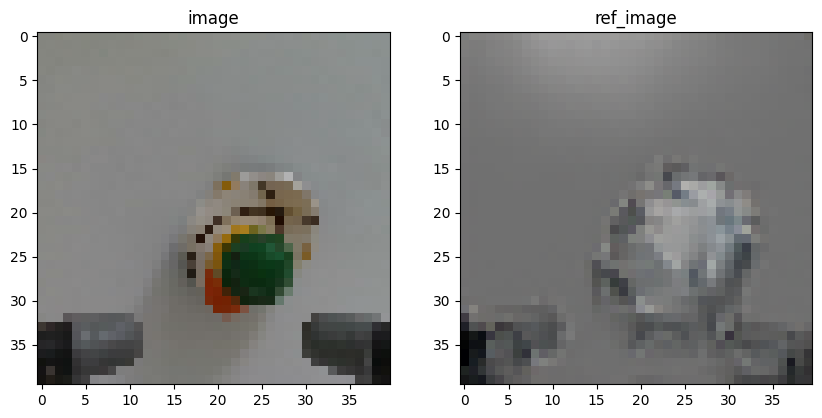

In [6]:
feat = image_encoder.encode(to_tensor(rgb_img))
decoded_img = image_encoder.decode(feat)
show_image(rgb_img,decoded_img[0])

In [7]:
s=env.get_state()

## Save & Load

In [4]:
from pick_env.utils import save_states, load_states

## Record

100%|██████████| 300/300 [00:03<00:00, 95.01it/s]


Start


[Tactile Perceptor] Warning: tactile state too old [True]
[Tactile Perceptor] Warning: tactile state too old [True]


  6%|▌         | 6/100 [00:00<00:05, 18.65it/s]

[Tactile Perceptor] Warning: tactile state too old [True]


...

[Tactile Perceptor] Warning: tactile state too old [True]
[Tactile Perceptor] Warning: tactile state too old [True]
[Tactile Perceptor] Warning: tactile state too old [True]
[Tactile Perceptor] Warning: tactile state too old [True]
[Tactile Perceptor] Warning: tactile state too old [True]


 96%|█████████▌| 96/100 [00:05<00:00, 18.68it/s]

[Tactile Perceptor] Warning: tactile state too old [True]
[Tactile Perceptor] Warning: tactile state too old [True]
[Tactile Perceptor] Warning: tactile state too old [True]
[Tactile Perceptor] Warning: tactile state too old [True]
[Tactile Perceptor] Warning: tactile state too old [True]


100%|██████████| 100/100 [00:05<00:00, 18.55it/s]

[Tactile Perceptor] Warning: tactile state too old [True]
[Tactile Perceptor] Warning: tactile state too old [True]
[Tactile Perceptor] Warning: tactile state too old [True]
[Tactile Perceptor] Warning: tactile state too old [True]
[Tactile Perceptor] Warning: tactile state too old [True]
End at: 5.392818450927734


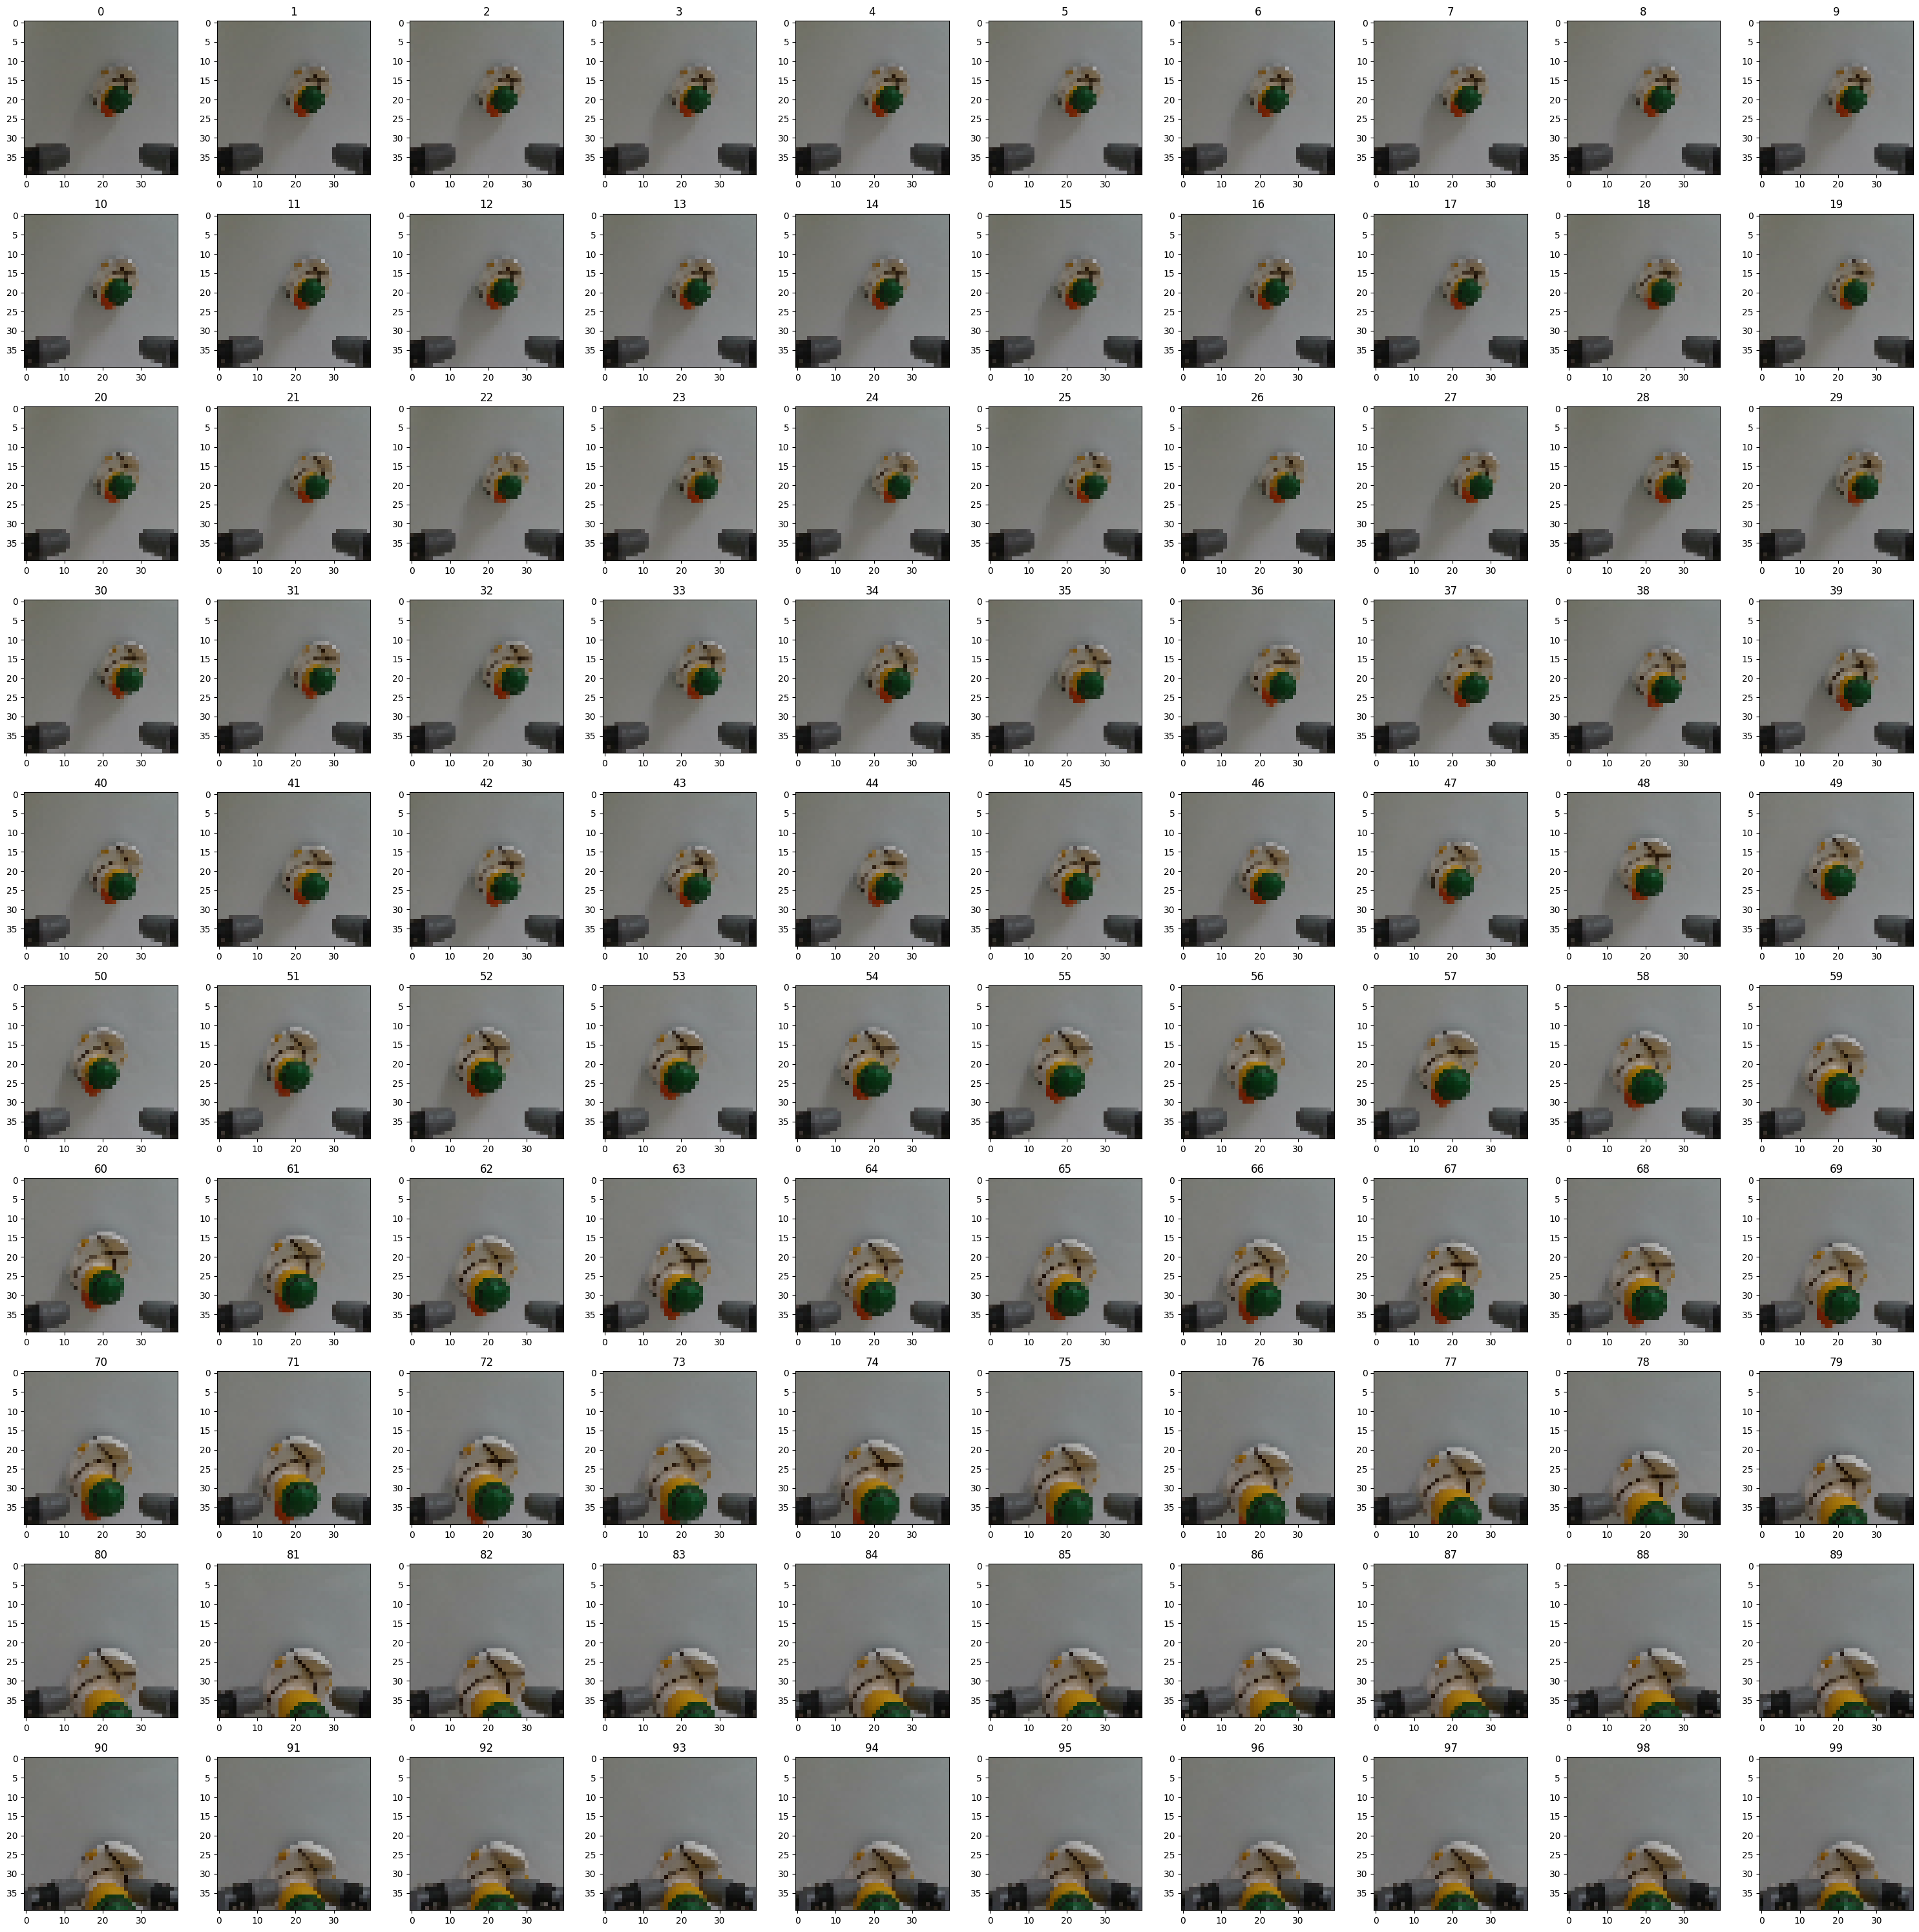

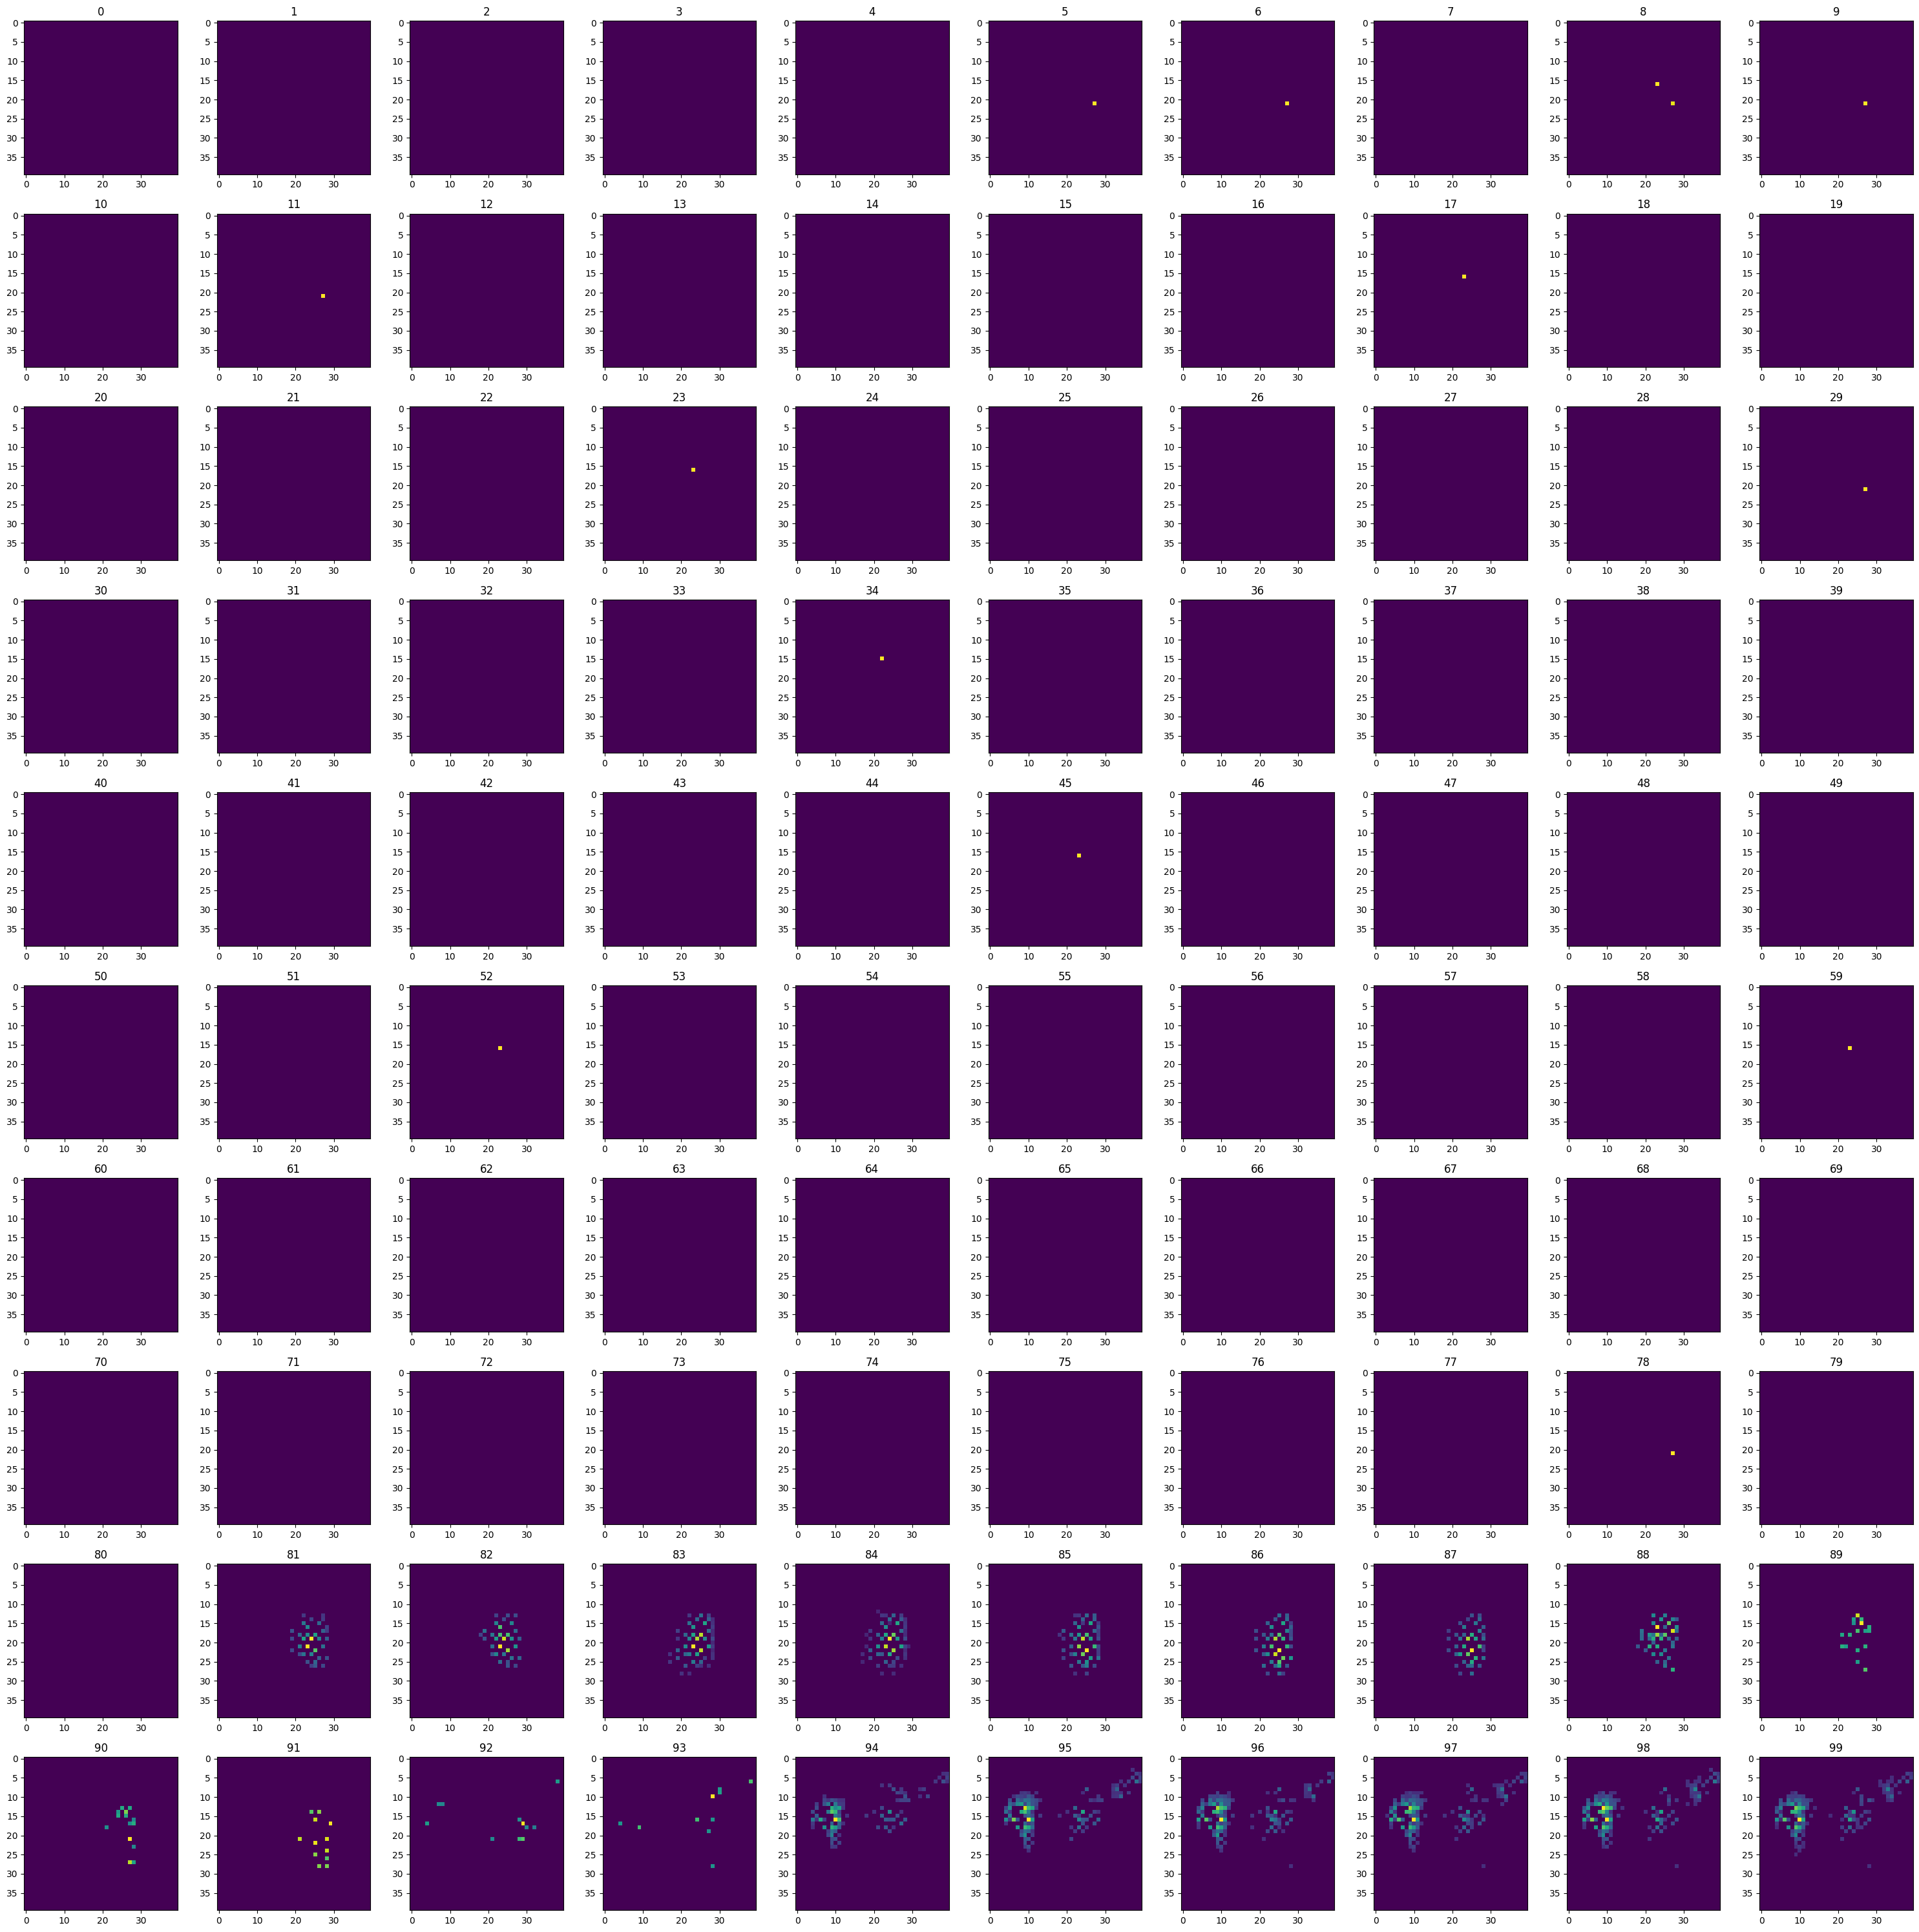

In [10]:
state_list = []
internal_state_list = []

import tqdm
env.robot.robot_interface.gripper_control(action=0.08)
for i in tqdm.trange(300):
    time.sleep(0.01)
print("Start")

tstart = time.time()
for i in tqdm.trange(100):
    env.robot.robot_interface.gripper_control(action=0.08*max(min((99-i)/20.0,1.0),0.4))
    time.sleep(0.05)
    state_list.append(deepcopy(env.get_state()[0]))
    internal_state_list.append(deepcopy(env.get_state()[1]))
    
print(f"End at: {time.time()-tstart}")


path = "data/recorded_trajectory/test" #0_0-04_0-032_toile-paper_force"

save_states(path=path,states=state_list)
show_images_from_states(states=state_list, show_tactile=False, save_path=path+"_rgb")
show_images_from_states(states=state_list, show_tactile=True, save_path=path+"_force")


In [33]:
save_states(path="data/recorded_trajectory/test",states=state_list)

In [5]:
test_states = load_states(path="data/recorded_trajectory/25_0-08_0-032_screw-box.npy", device="cuda")

In [13]:
for i in range(100):
    a = np.concatenate([test_states[i].robot_joint_positions.cpu().numpy()[0],test_states[i].robot_tcp_opening.cpu().numpy()[0]],axis=-1)
    print(a)

[ 0.33079725 -0.17552319 -0.22257209 -1.98156863 -0.00215438  1.70892946
  1.06530966  0.03999634]
[ 0.33076981 -0.17552749 -0.22260579 -1.98156406 -0.00217085  1.70891591
  1.06531553  0.03999634]
[ 0.33075906 -0.17551604 -0.22262022 -1.98157953 -0.0021744   1.70891035
  1.06530699  0.03999634]
[ 0.33077349 -0.17553047 -0.22260157 -1.98156297 -0.00216113  1.70892669
  1.06530808  0.03999634]
[ 0.330746   -0.17552566 -0.22263769 -1.98158172 -0.00215981  1.70890689
  1.06530949  0.03999634]
[ 0.33069396 -0.17548711 -0.22277804 -1.98162084 -0.00216785  1.70889447
  1.0653134   0.03999634]
[ 0.33070619 -0.17546612 -0.22276164 -1.98162088 -0.00217237  1.7089281
  1.06531444  0.03999634]
[ 0.33105524 -0.17486418 -0.22248334 -1.98163821 -0.00212193  1.70895974
  1.06527685  0.03999634]
[ 3.33565174e-01 -1.70191651e-01 -2.22391574e-01 -1.98158199e+00
 -1.56973061e-03  1.70917950e+00  1.06525162e+00  3.99963370e-02]
[ 3.36826359e-01 -1.62108332e-01 -2.22371474e-01 -1.98156437e+00
 -1.08352843e